# CFD Field Visualization

Visualize **pressure (p)** and **velocity (U)** fields from the exported `.npz` point-cloud data.

Each `.npz` file contains:
- `coords` — (N, 2) cell-centre coordinates (x, y)
- `U` — (N, 2) velocity vector (Ux, Uy)
- `p` — (N,) kinematic pressure

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from pathlib import Path
import csv

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (16, 6)

## 2. Configuration

Select which case to visualize. Change `CASE_NAME` to any model from `data_car.csv`.

In [2]:
# ── Configuration ─────────────────────────────────────────────
NPZ_DIR = Path("/home/nicksung/Desktop/nicksung/mf_field/lf_data/npz_data")
CSV_PATH = Path("/home/nicksung/Desktop/nicksung/mf_field/lf_data/data_car.csv")

# Pick a case to visualize (change this to explore different geometries)
CASE_NAME = "E_S_WWC_WM_005"

# List first 10 available cases for reference
available = sorted([f.stem for f in NPZ_DIR.glob("*.npz")])
print(f"Total available cases: {len(available)}")
print(f"First 10: {available[:10]}")

Total available cases: 3991
First 10: ['E_S_WWC_WM_005', 'E_S_WWC_WM_006', 'E_S_WWC_WM_007', 'E_S_WWC_WM_008', 'E_S_WWC_WM_009', 'E_S_WWC_WM_010', 'E_S_WWC_WM_011', 'E_S_WWC_WM_012', 'E_S_WWC_WM_013', 'E_S_WWC_WM_014']


## 3. Load Data

In [3]:
# Load the .npz file
data = np.load(NPZ_DIR / f"{CASE_NAME}.npz", allow_pickle=True)

coords = data["coords"]   # (N, 2)
U = data["U"]              # (N, 2)
p = data["p"]              # (N,)

x, y = coords[:, 0], coords[:, 1]
Ux, Uy = U[:, 0], U[:, 1]
U_mag = np.sqrt(Ux**2 + Uy**2)

print(f"Case: {CASE_NAME}")
print(f"  Cells:    {len(p):,}")
print(f"  x range:  [{x.min():.2f}, {x.max():.2f}]")
print(f"  y range:  [{y.min():.2f}, {y.max():.2f}]")
print(f"  p range:  [{p.min():.1f}, {p.max():.1f}]")
print(f"  |U| range:[{U_mag.min():.2f}, {U_mag.max():.2f}]")

Case: E_S_WWC_WM_005
  Cells:    311,226
  x range:  [-14.83, 50.66]
  y range:  [0.00, 6.33]
  p range:  [-2584.3, 484.8]
  |U| range:[0.00, 67.88]


## 4. Triangulation

Build a Delaunay triangulation from cell centres for smooth contour plots.

In [4]:
# Create Delaunay triangulation from cell centres
triang = tri.Triangulation(x, y)

# Optional: mask very long triangles (spanning the domain, not physical)
# This removes spurious triangles that connect distant points
edges = triang.triangles
x_tri = x[edges]
y_tri = y[edges]
# Max edge length per triangle
dx = np.max(np.abs(np.diff(x_tri, axis=1, append=x_tri[:, :1])), axis=1)
dy = np.max(np.abs(np.diff(y_tri, axis=1, append=y_tri[:, :1])), axis=1)
max_edge = np.sqrt(dx**2 + dy**2)
# Mask triangles with edges > 95th percentile (removes non-physical long triangles)
threshold = np.percentile(max_edge, 97)
triang.set_mask(max_edge > threshold)

print(f"Triangulation: {len(triang.triangles)} triangles, {threshold:.3f} max edge threshold")

Triangulation: 622428 triangles, 0.130 max edge threshold


## 5. Pressure Field (p)

Filled contour plot of kinematic pressure $p / \rho$ over the domain.

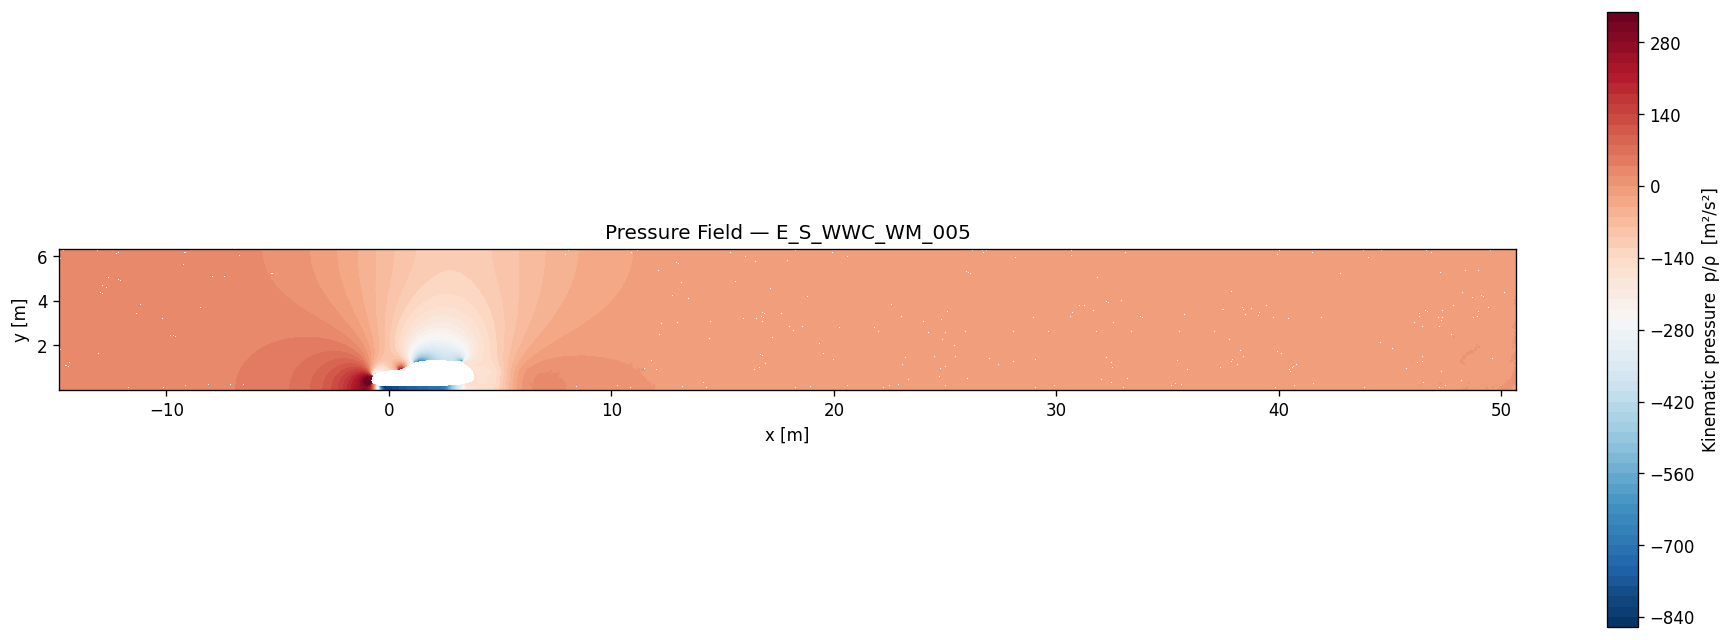

In [5]:
# Clip pressure to remove extreme outliers for better color range
p_clip = np.clip(p, np.percentile(p, 1), np.percentile(p, 99))

fig, ax = plt.subplots(1, 1, figsize=(16, 6))
tcf = ax.tricontourf(triang, p_clip, levels=64, cmap="RdBu_r")
cbar = fig.colorbar(tcf, ax=ax, label="Kinematic pressure  p/ρ  [m²/s²]", shrink=0.9)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title(f"Pressure Field — {CASE_NAME}")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 6. Velocity Magnitude Field (|U|)

Filled contour plot of velocity magnitude $|U| = \sqrt{U_x^2 + U_y^2}$.

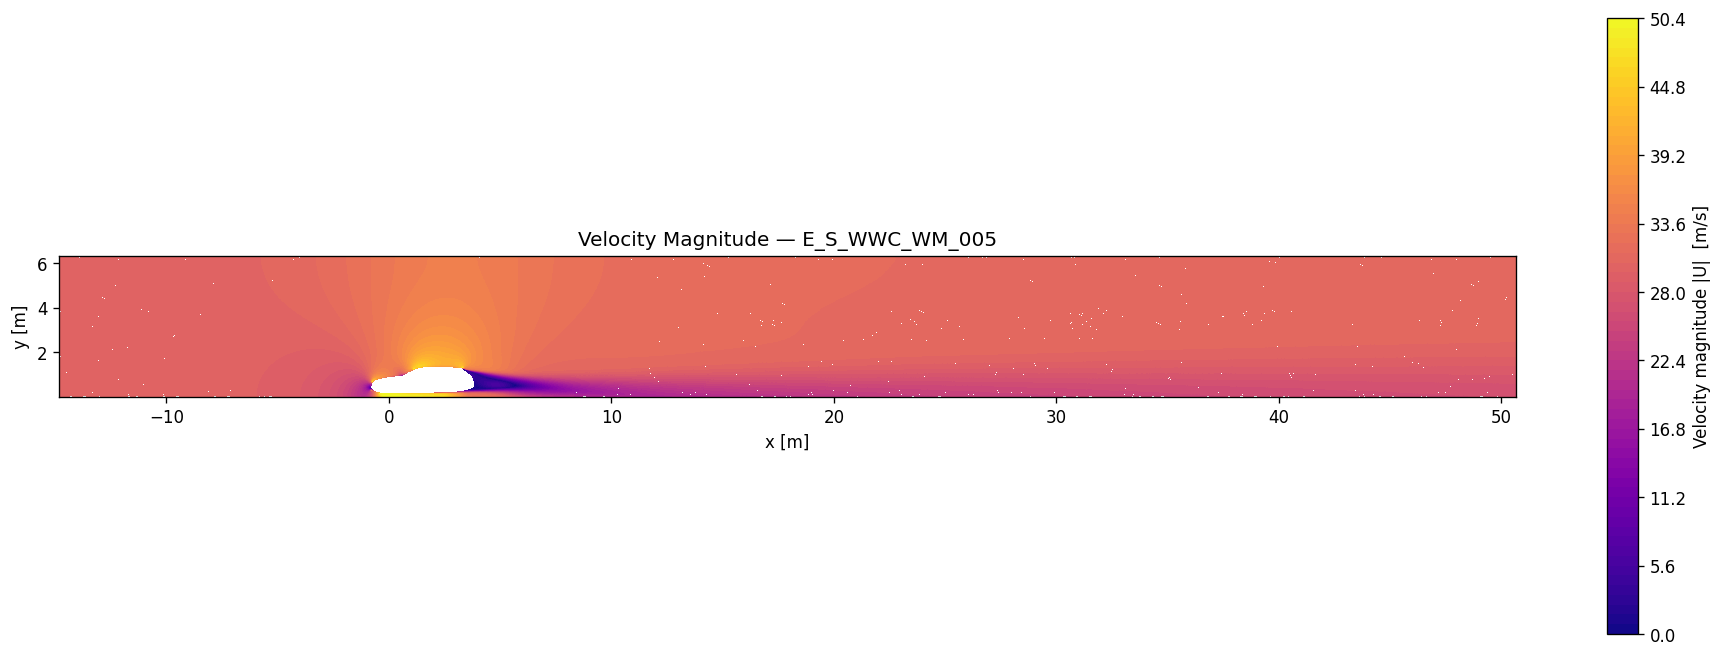

In [6]:
U_mag_clip = np.clip(U_mag, 0, np.percentile(U_mag, 99))

fig, ax = plt.subplots(1, 1, figsize=(16, 6))
tcf = ax.tricontourf(triang, U_mag_clip, levels=64, cmap="plasma")
cbar = fig.colorbar(tcf, ax=ax, label="Velocity magnitude |U|  [m/s]", shrink=0.9)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title(f"Velocity Magnitude — {CASE_NAME}")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 7. Side-by-Side Comparison

Both fields plotted together for easy comparison.

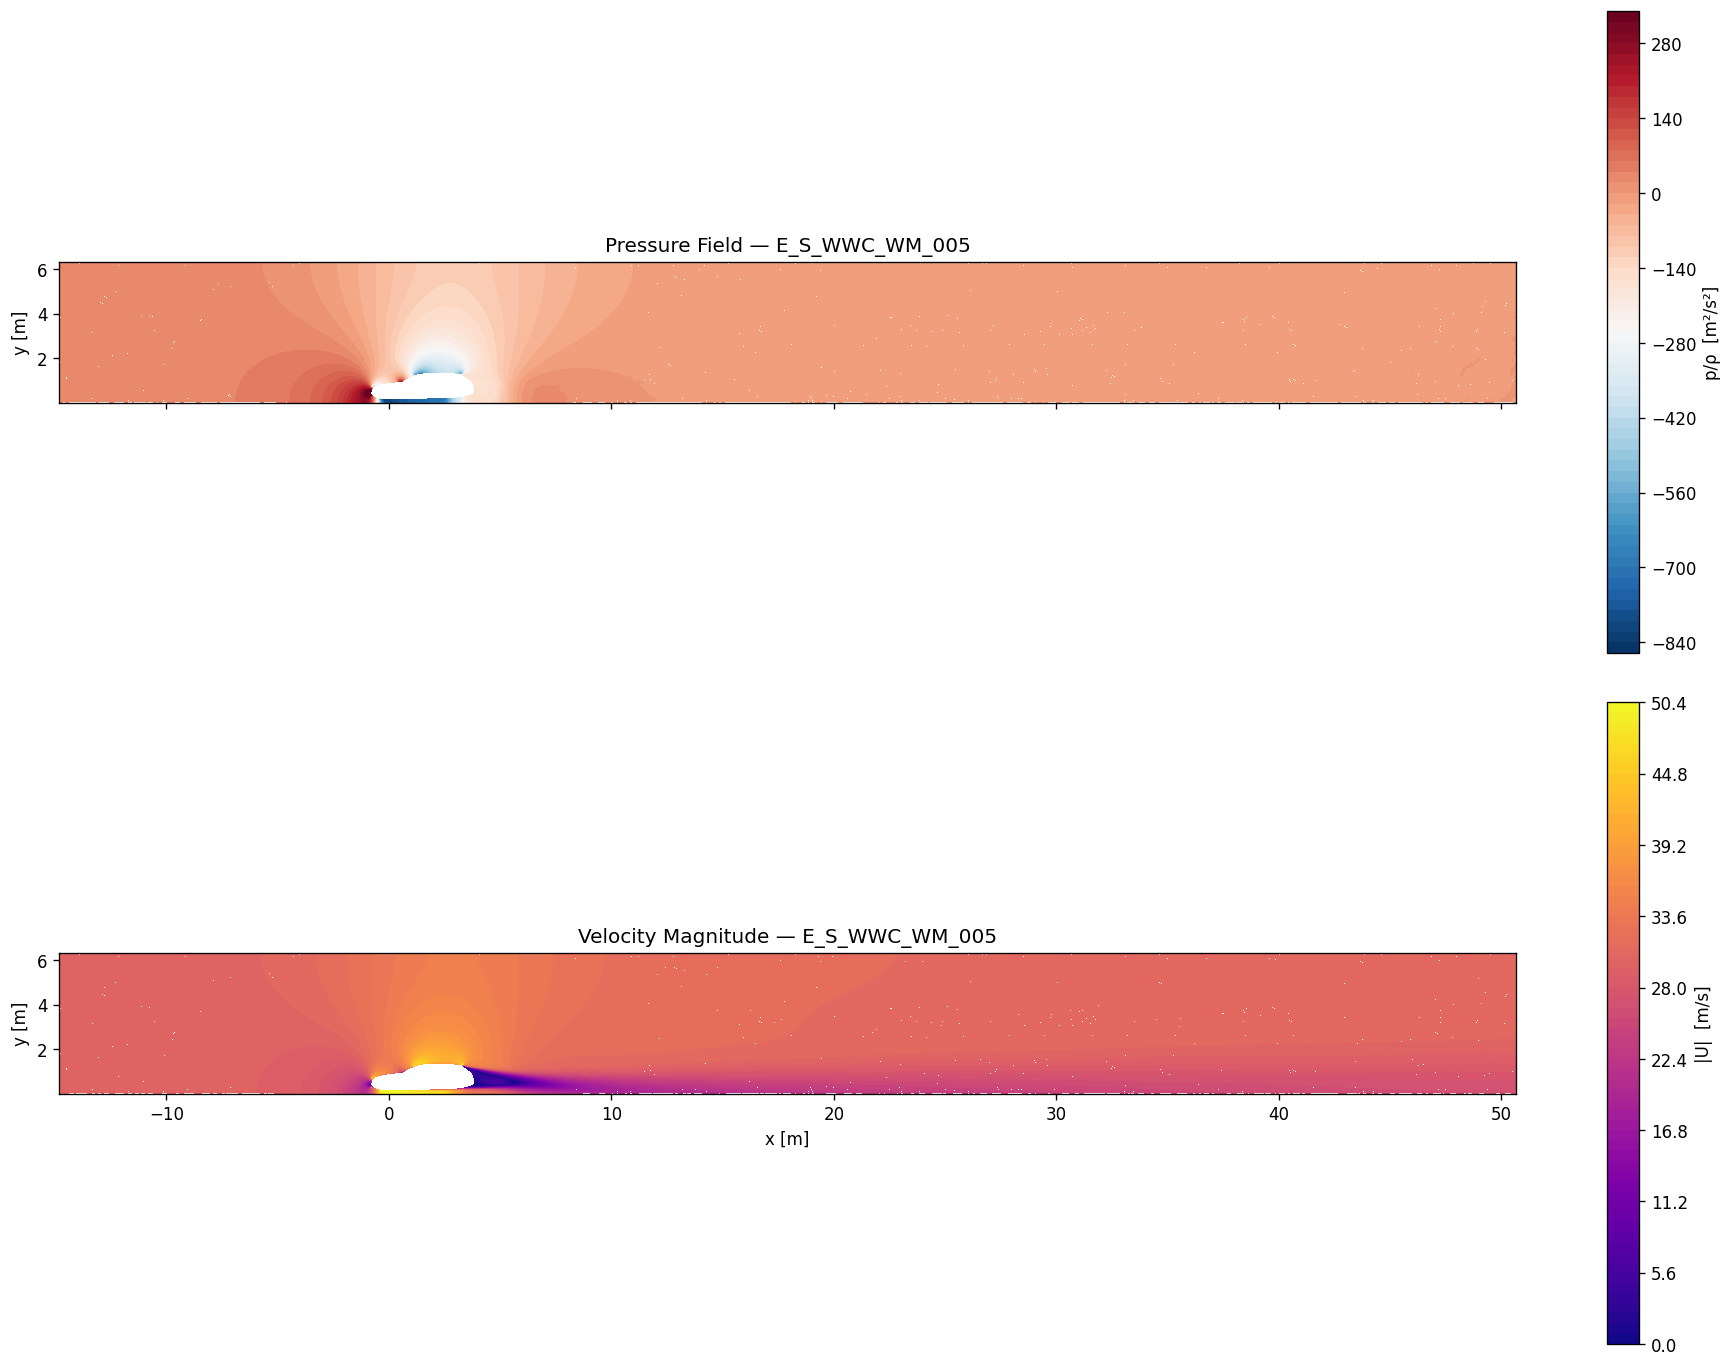

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# Pressure
tcf1 = axes[0].tricontourf(triang, p_clip, levels=64, cmap="RdBu_r")
fig.colorbar(tcf1, ax=axes[0], label="p/ρ  [m²/s²]", shrink=0.9)
axes[0].set_ylabel("y [m]")
axes[0].set_title(f"Pressure Field — {CASE_NAME}")
axes[0].set_aspect("equal")

# Velocity magnitude
tcf2 = axes[1].tricontourf(triang, U_mag_clip, levels=64, cmap="plasma")
fig.colorbar(tcf2, ax=axes[1], label="|U|  [m/s]", shrink=0.9)
axes[1].set_xlabel("x [m]")
axes[1].set_ylabel("y [m]")
axes[1].set_title(f"Velocity Magnitude — {CASE_NAME}")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

## 8. Velocity Vector Plot (Quiver)

Subsample the velocity field and show direction arrows overlaid on the velocity magnitude contour. Zoomed into a region near the car body for detail.

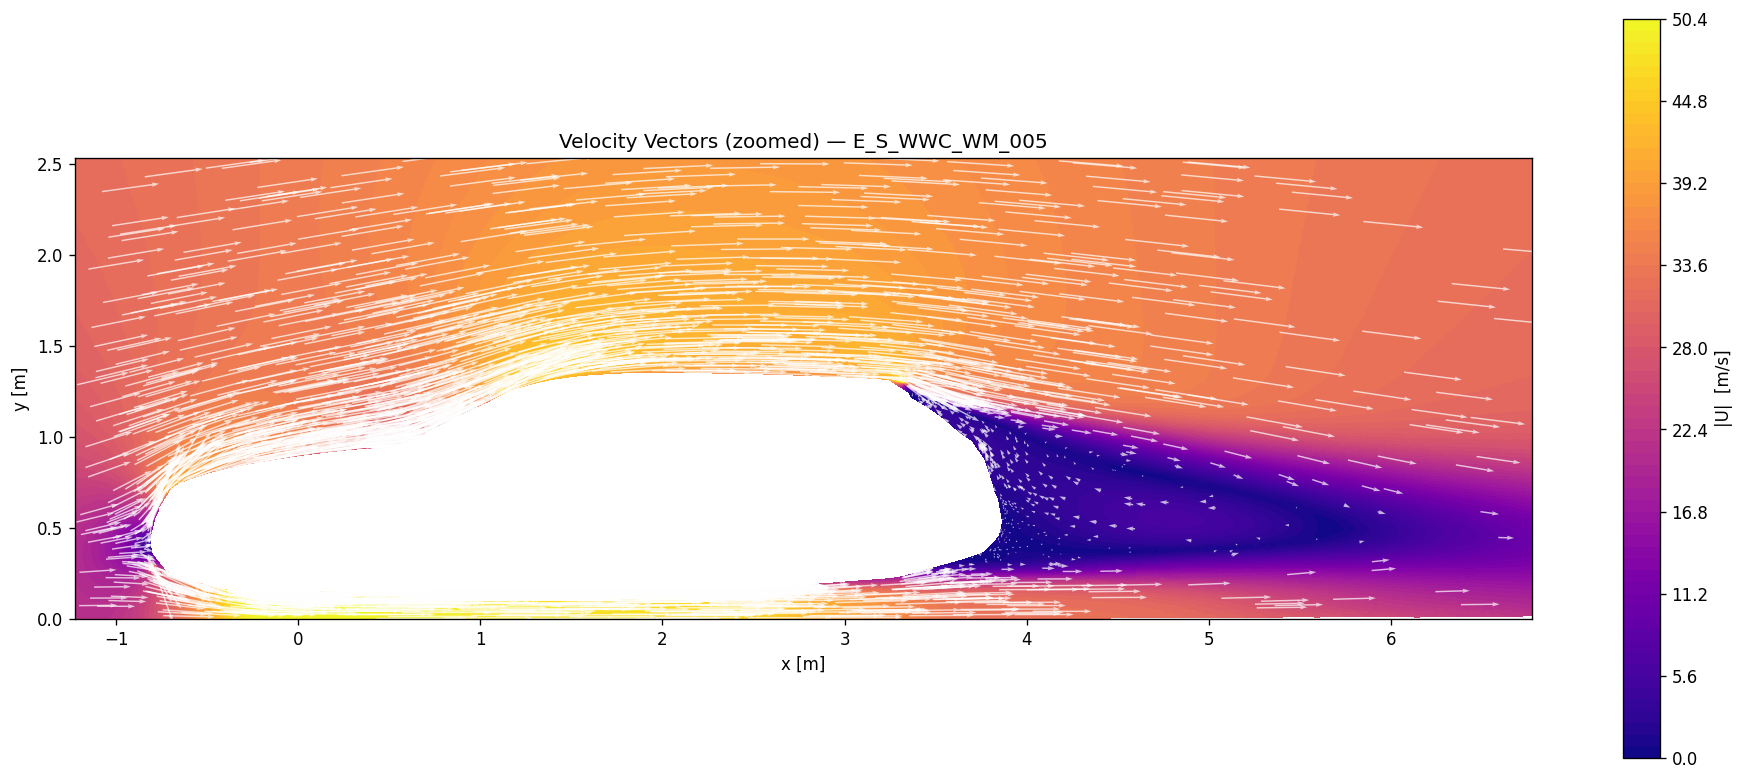

In [8]:
# Zoom region around the car body
x_mid = np.median(x)
y_max = np.max(y)
x_lo, x_hi = x_mid - 3, x_mid + 5
y_lo, y_hi = 0, y_max * 0.4

# Select points in zoom region
mask = (x >= x_lo) & (x <= x_hi) & (y >= y_lo) & (y <= y_hi)

# Subsample for legible arrows (every Nth point)
n_arrows = 3000
idx_zoom = np.where(mask)[0]
if len(idx_zoom) > n_arrows:
    step = len(idx_zoom) // n_arrows
    idx_zoom = idx_zoom[::step]

fig, ax = plt.subplots(1, 1, figsize=(16, 8))

# Background contour
tcf = ax.tricontourf(triang, U_mag_clip, levels=64, cmap="plasma")
fig.colorbar(tcf, ax=ax, label="|U|  [m/s]", shrink=0.8)

# Quiver arrows
ax.quiver(
    x[idx_zoom], y[idx_zoom],
    Ux[idx_zoom], Uy[idx_zoom],
    color="white", alpha=0.7,
    scale=800, width=0.001, headwidth=3,
)

ax.set_xlim(x_lo, x_hi)
ax.set_ylim(y_lo, y_hi)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title(f"Velocity Vectors (zoomed) — {CASE_NAME}")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 9. Compare Multiple Cases

Load and compare pressure/velocity fields across several geometries.

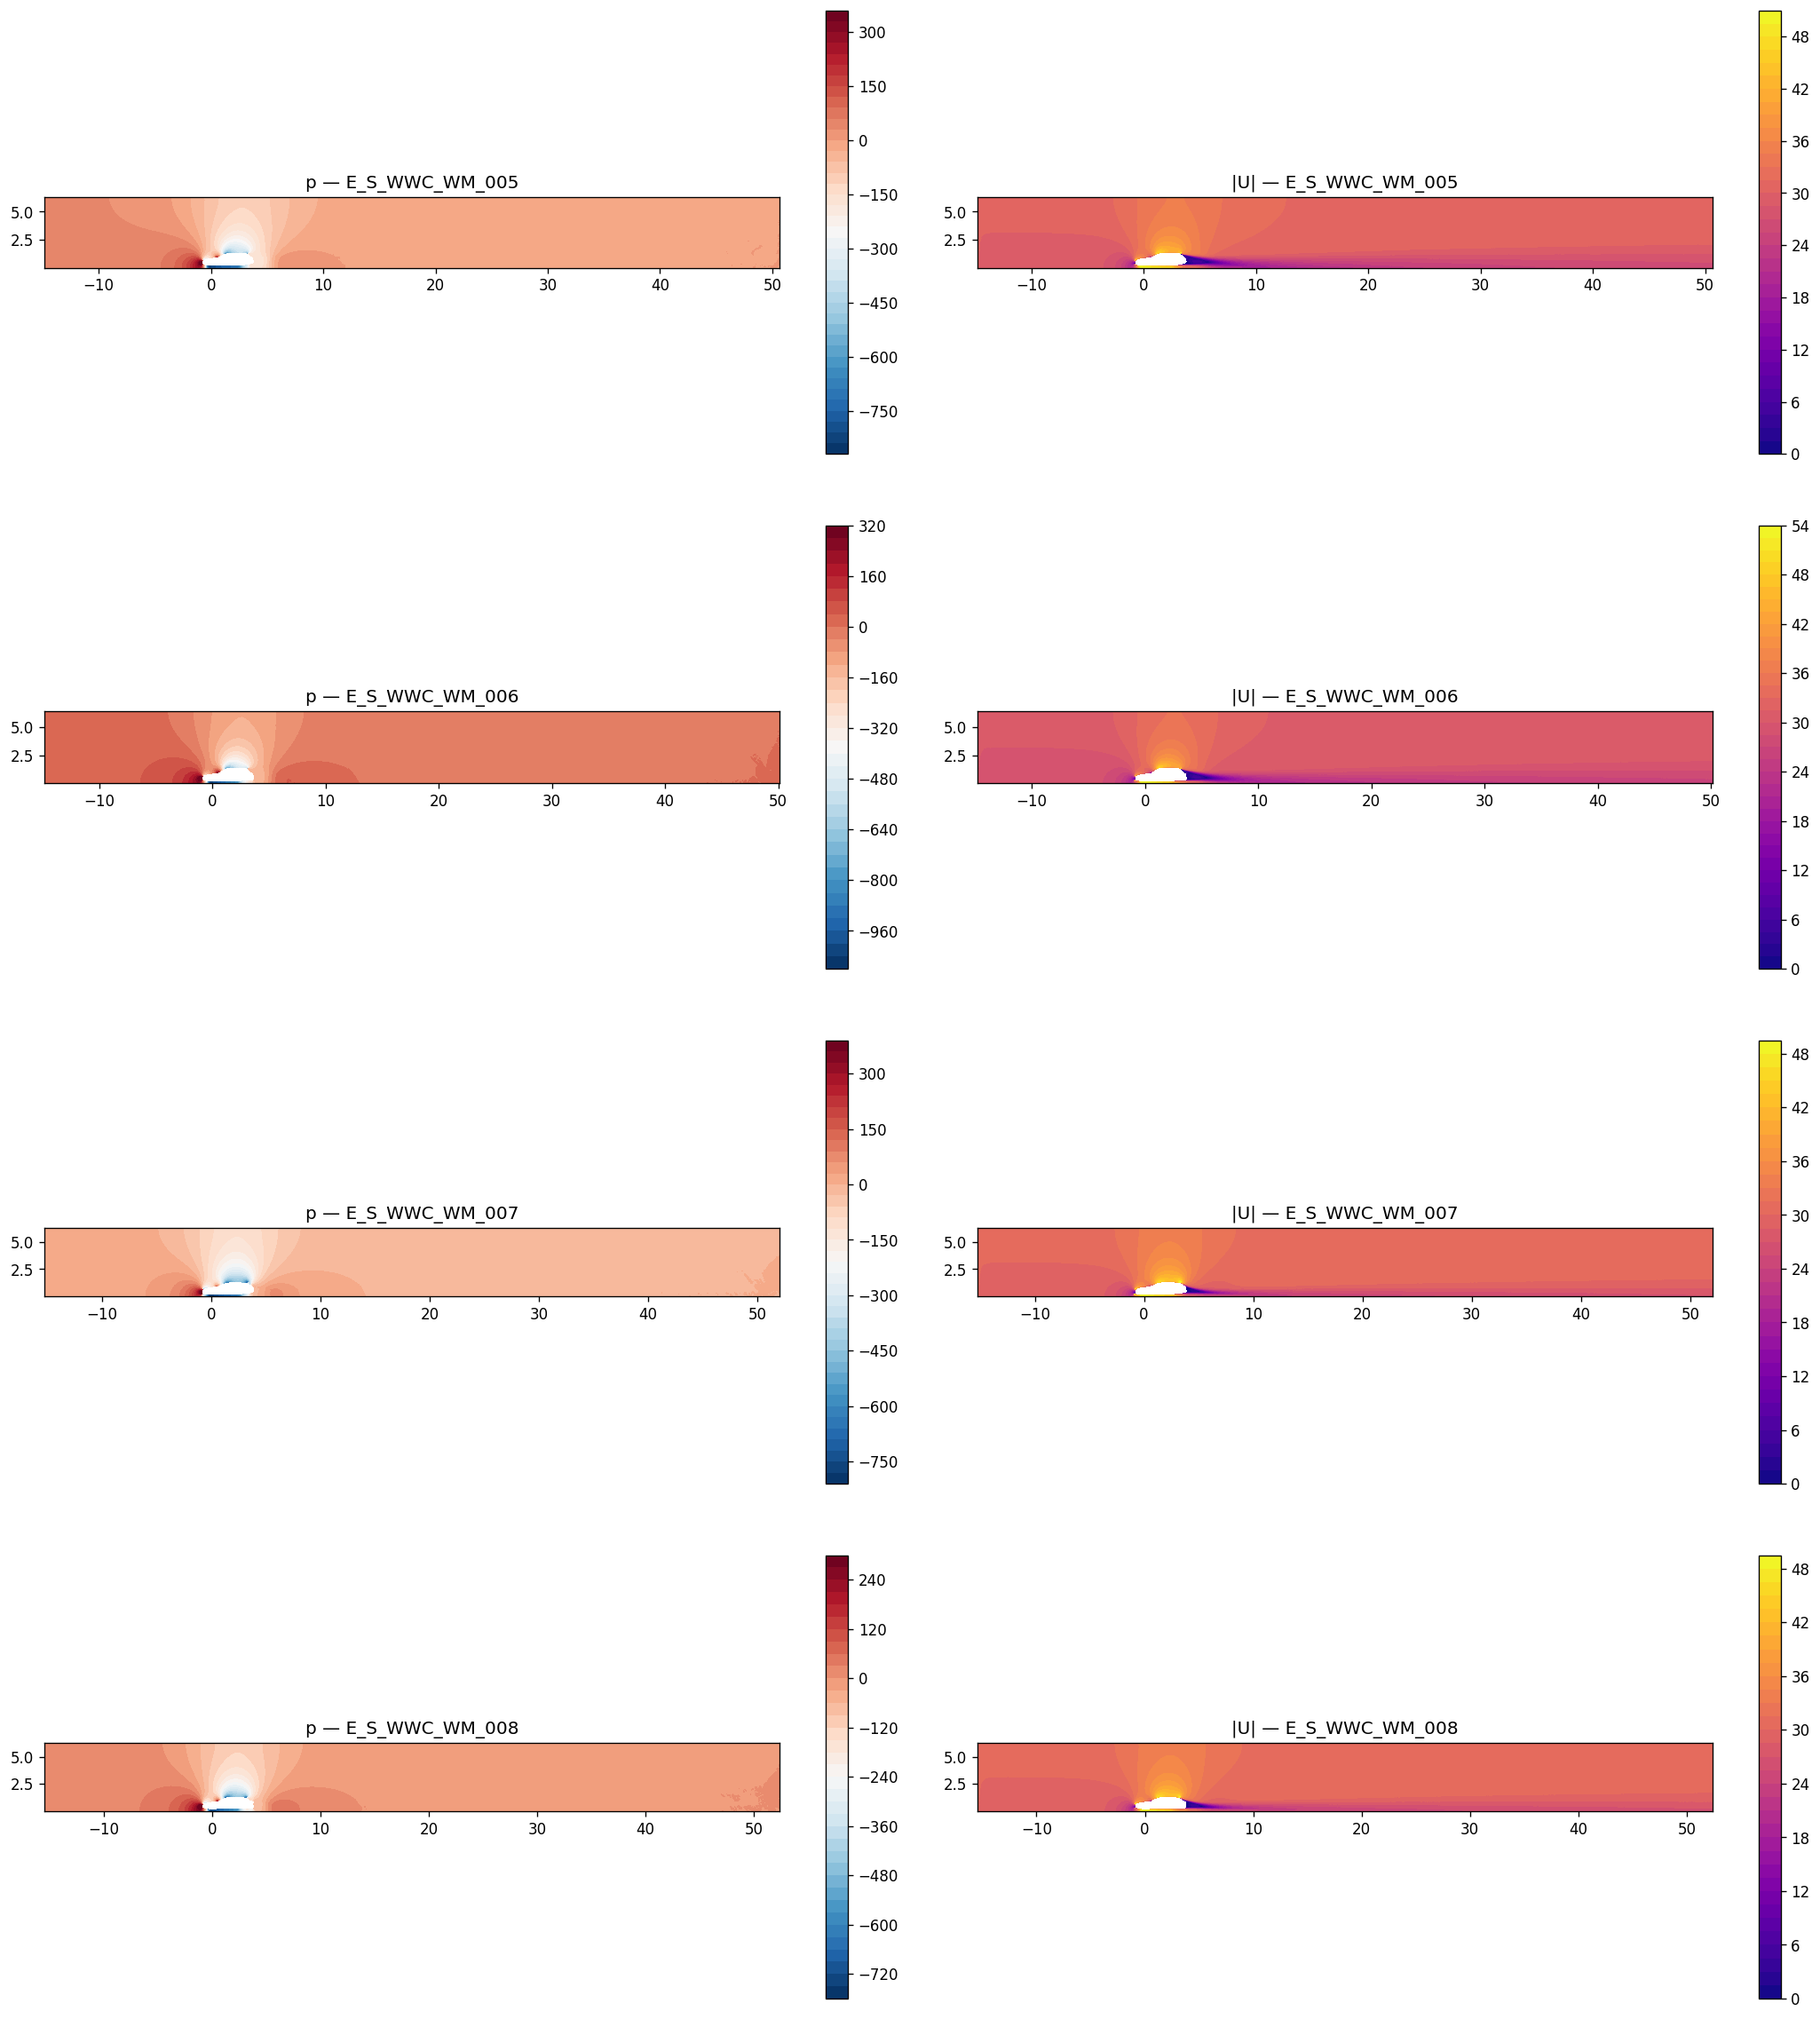

In [9]:
# Compare 4 different cases
compare_cases = available[:4]  # Change these to whichever cases you want

fig, axes = plt.subplots(len(compare_cases), 2, figsize=(18, 5 * len(compare_cases)))

for i, case in enumerate(compare_cases):
    d = np.load(NPZ_DIR / f"{case}.npz")
    cx, cy = d["coords"][:, 0], d["coords"][:, 1]
    cp = d["p"]
    cU = np.sqrt(d["U"][:, 0]**2 + d["U"][:, 1]**2)

    # Triangulate
    ct = tri.Triangulation(cx, cy)
    edges = ct.triangles
    x_t, y_t = cx[edges], cy[edges]
    dx_ = np.max(np.abs(np.diff(x_t, axis=1, append=x_t[:, :1])), axis=1)
    dy_ = np.max(np.abs(np.diff(y_t, axis=1, append=y_t[:, :1])), axis=1)
    me = np.sqrt(dx_**2 + dy_**2)
    ct.set_mask(me > np.percentile(me, 97))

    # Pressure
    pc = np.clip(cp, np.percentile(cp, 1), np.percentile(cp, 99))
    tcf1 = axes[i, 0].tricontourf(ct, pc, levels=40, cmap="RdBu_r")
    fig.colorbar(tcf1, ax=axes[i, 0], shrink=0.8)
    axes[i, 0].set_title(f"p — {case}")
    axes[i, 0].set_aspect("equal")

    # Velocity
    uc = np.clip(cU, 0, np.percentile(cU, 99))
    tcf2 = axes[i, 1].tricontourf(ct, uc, levels=40, cmap="plasma")
    fig.colorbar(tcf2, ax=axes[i, 1], shrink=0.8)
    axes[i, 1].set_title(f"|U| — {case}")
    axes[i, 1].set_aspect("equal")

plt.tight_layout()
plt.show()

---

## 10. Car Surface Fields

Load the car-wall surface data extracted by `export_surface_to_npz.py`.
These files contain the **pressure and near-wall velocity** sampled on the `carWall` boundary patch.

Each `*_surface.npz` file contains:
- `surf_coords` — (M, 2) face-centre coordinates on the car wall
- `surf_p` — (M,) wall pressure
- `surf_U` — (M, 2) near-wall velocity

In [11]:
# ── Load car surface data ─────────────────────────────────────
# ── Configuration ─────────────────────────────────────────────
SURF_DIR = Path("/home/nicksung/Desktop/nicksung/mf_field/lf_data/npz_surface_data")

surf_file = SURF_DIR / f"{CASE_NAME}_surface.npz"
surf = np.load(surf_file, allow_pickle=True)

s_coords = surf["surf_coords"]  # (M, 2)
s_p = surf["surf_p"]            # (M,)
s_U = surf["surf_U"]            # (M, 2)
s_x, s_y = s_coords[:, 0], s_coords[:, 1]
s_Umag = np.sqrt(s_U[:, 0]**2 + s_U[:, 1]**2)

print(f"Case: {CASE_NAME}")
print(f"  Surface faces: {len(s_p):,}")
print(f"  x range: [{s_x.min():.3f}, {s_x.max():.3f}]")
print(f"  y range: [{s_y.min():.3f}, {s_y.max():.3f}]")
print(f"  p range: [{s_p.min():.1f}, {s_p.max():.1f}]")
print(f"  |U| range: [{s_Umag.min():.2f}, {s_Umag.max():.2f}]")

Case: E_S_WWC_WM_005
  Surface faces: 3,405
  x range: [-0.809, 3.872]
  y range: [0.147, 1.352]
  p range: [-2584.3, 484.8]
  |U| range: [0.02, 66.67]


### 10a. Car Surface Geometry

Plot the car wall face centres to see the car shape.

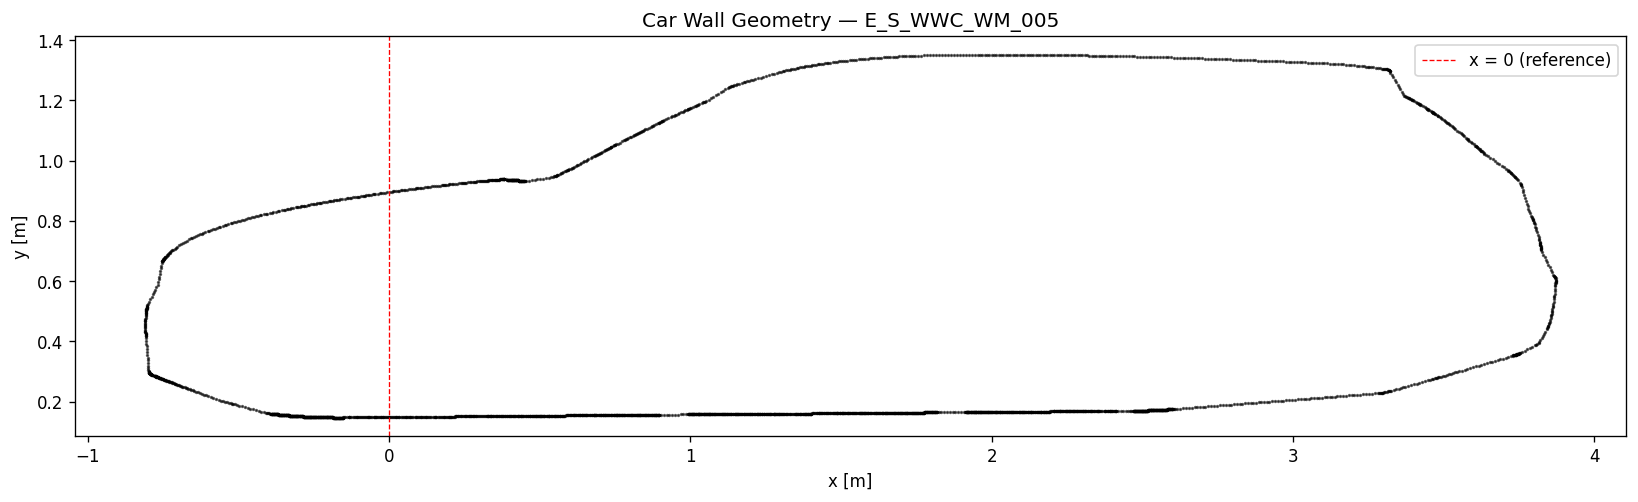

In [12]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.scatter(s_x, s_y, c="k", s=1, alpha=0.6)
ax.axvline(0, color="red", ls="--", lw=0.8, label="x = 0 (reference)")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title(f"Car Wall Geometry — {CASE_NAME}")
ax.set_aspect("equal")
ax.legend()
plt.tight_layout()
plt.show()

### 10b. Surface Pressure Distribution

Pressure $p / \rho$ along the car surface, colour-coded on the car outline and plotted vs arc-length.

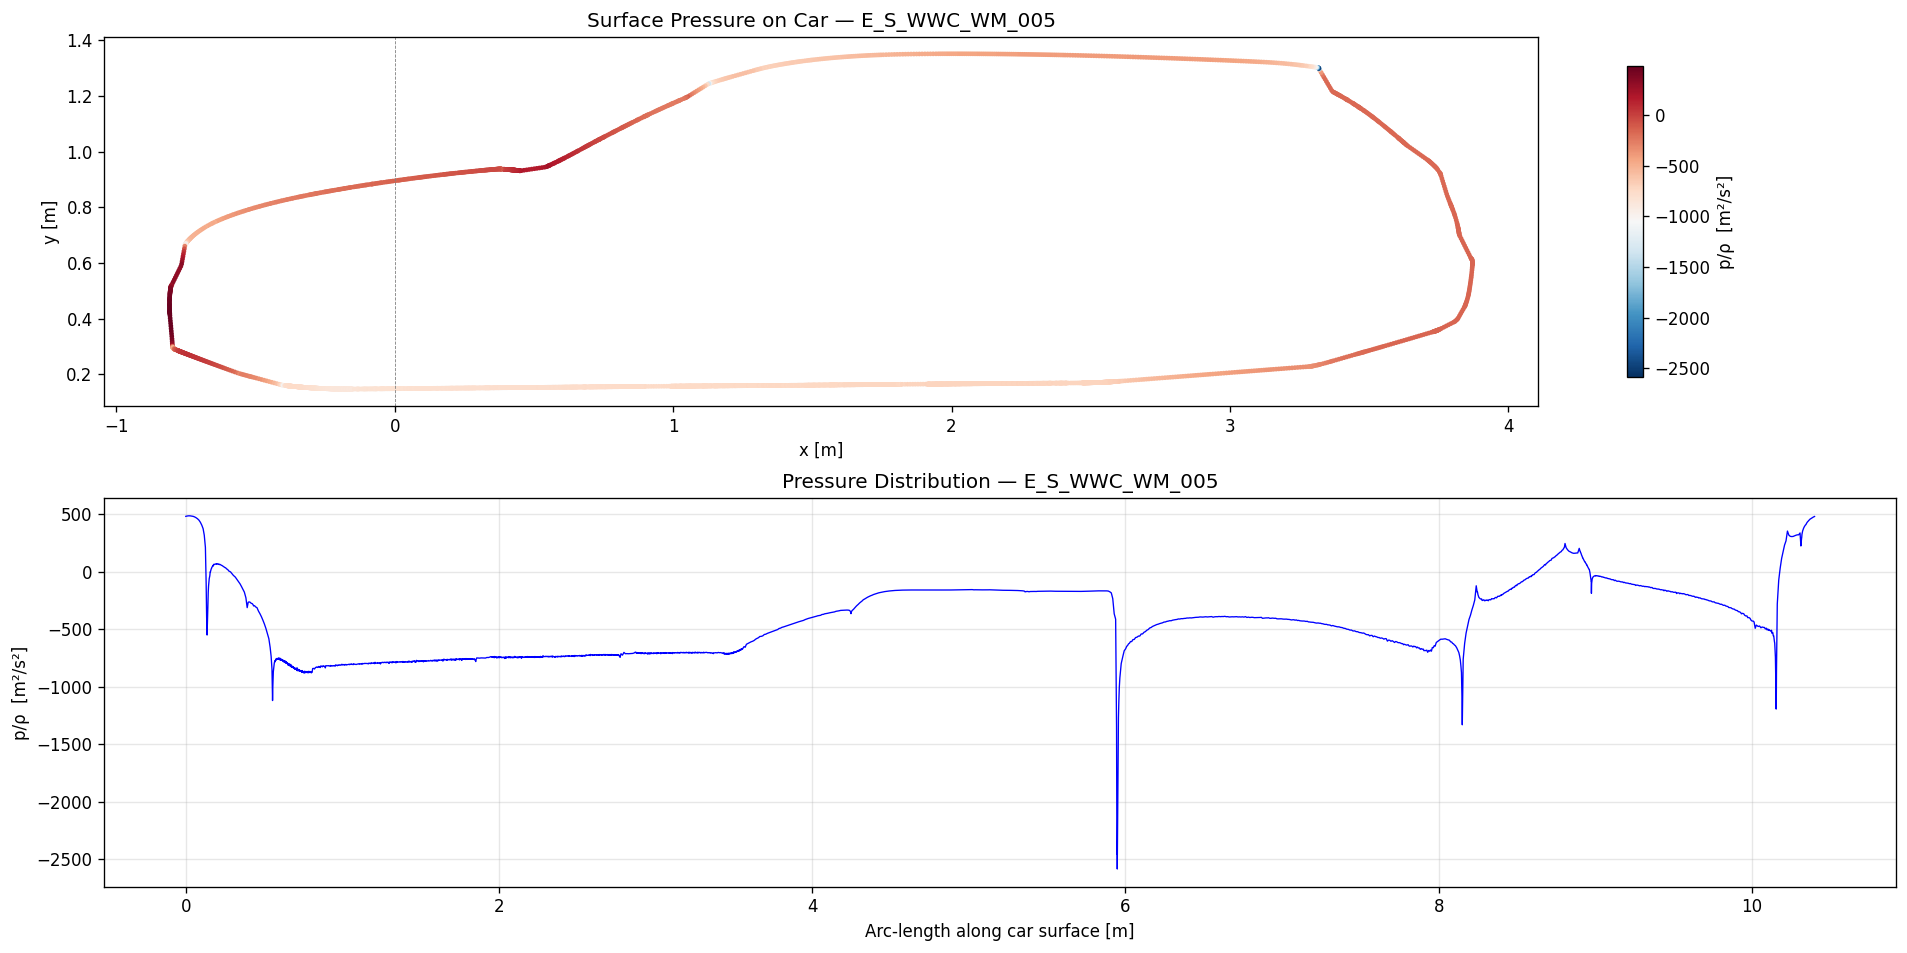

In [13]:
# Compute arc-length along the car surface
ds = np.sqrt(np.diff(s_x)**2 + np.diff(s_y)**2)
arc = np.concatenate([[0], np.cumsum(ds)])

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# ── Top: colour-coded car outline ───────────────────────────
sc = axes[0].scatter(s_x, s_y, c=s_p, s=8, cmap="RdBu_r", edgecolors="none")
fig.colorbar(sc, ax=axes[0], label="p/ρ  [m²/s²]", shrink=0.8)
axes[0].axvline(0, color="gray", ls="--", lw=0.5)
axes[0].set_xlabel("x [m]")
axes[0].set_ylabel("y [m]")
axes[0].set_title(f"Surface Pressure on Car — {CASE_NAME}")
axes[0].set_aspect("equal")

# ── Bottom: pressure vs arc-length ──────────────────────────
axes[1].plot(arc, s_p, "b-", lw=0.8)
axes[1].set_xlabel("Arc-length along car surface [m]")
axes[1].set_ylabel("p/ρ  [m²/s²]")
axes[1].set_title(f"Pressure Distribution — {CASE_NAME}")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

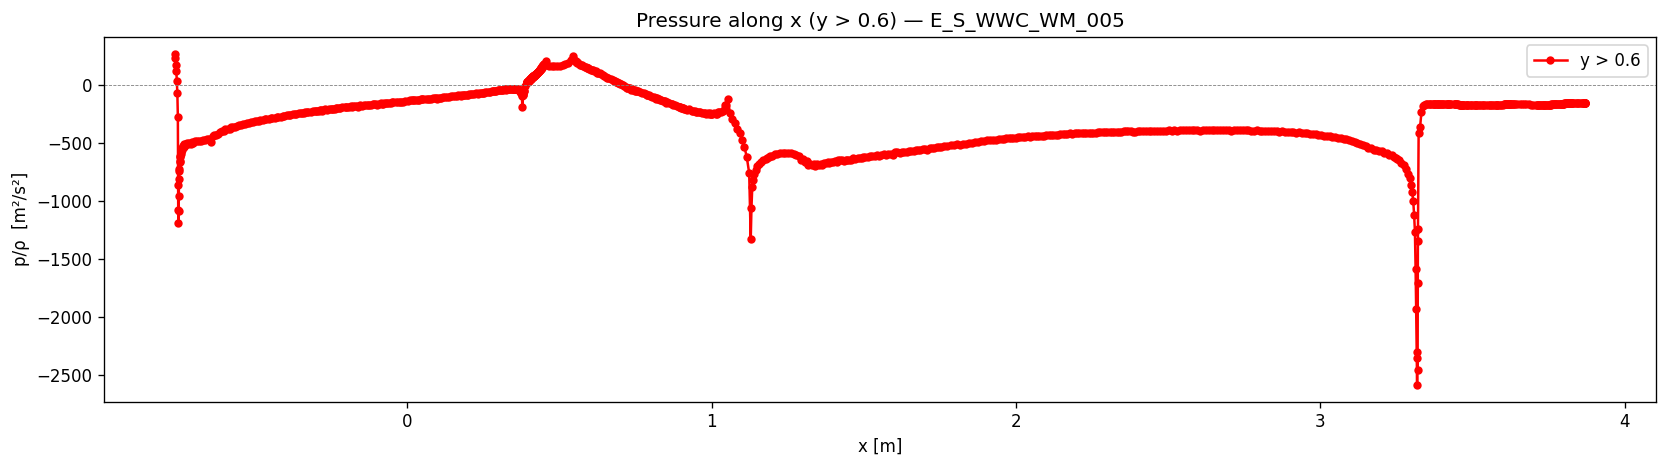

In [14]:
# plot the pressure distribution along x for y more than o.6
mask = s_y > 0.6
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(s_x[mask], s_p[mask], "ro-", markersize=4, label="y > 0.6")
ax.axhline(0, color="gray", ls="--", lw=0.5)
ax.set_xlabel("x [m]")
ax.set_ylabel("p/ρ  [m²/s²]")
ax.set_title(f"Pressure along x (y > 0.6) — {CASE_NAME}")
ax.legend()
plt.tight_layout()
plt.show()

### 10c. Surface Velocity Distribution

Near-wall velocity magnitude along the car surface.

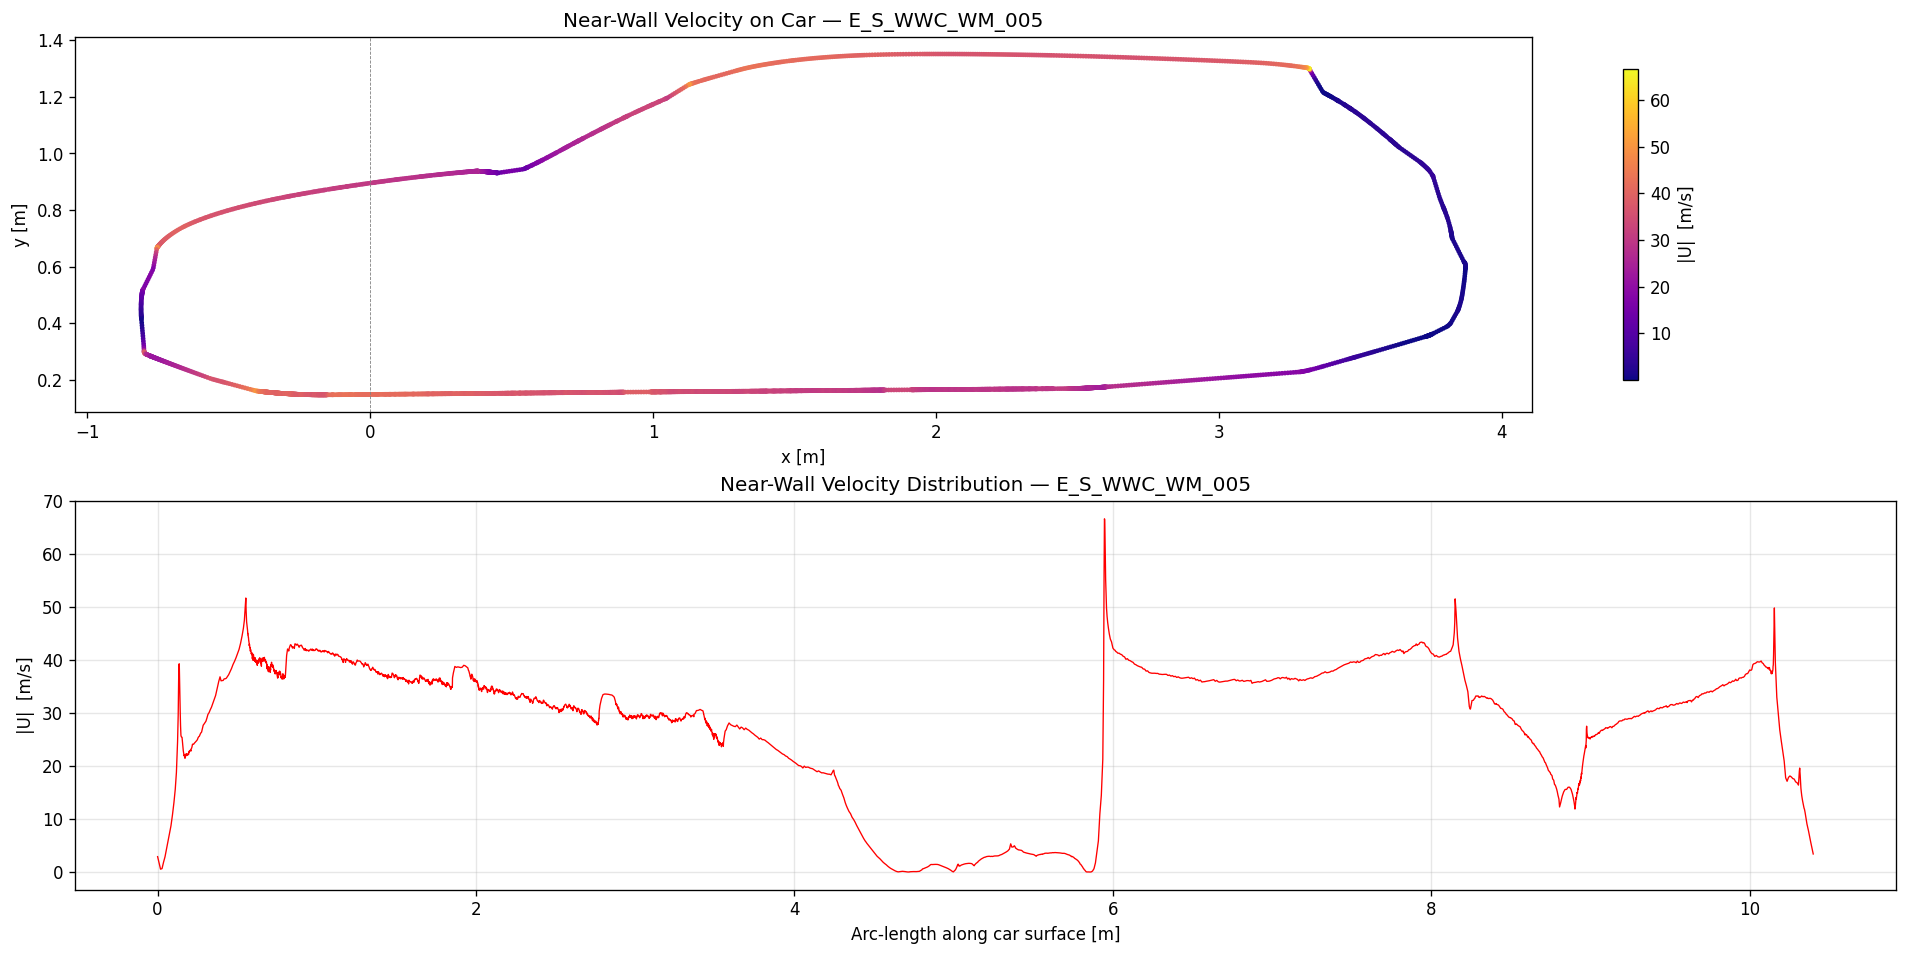

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# ── Top: colour-coded car outline ───────────────────────────
sc = axes[0].scatter(s_x, s_y, c=s_Umag, s=8, cmap="plasma", edgecolors="none")
fig.colorbar(sc, ax=axes[0], label="|U|  [m/s]", shrink=0.8)
axes[0].axvline(0, color="gray", ls="--", lw=0.5)
axes[0].set_xlabel("x [m]")
axes[0].set_ylabel("y [m]")
axes[0].set_title(f"Near-Wall Velocity on Car — {CASE_NAME}")
axes[0].set_aspect("equal")

# ── Bottom: velocity vs arc-length ──────────────────────────
axes[1].plot(arc, s_Umag, "r-", lw=0.8)
axes[1].set_xlabel("Arc-length along car surface [m]")
axes[1].set_ylabel("|U|  [m/s]")
axes[1].set_title(f"Near-Wall Velocity Distribution — {CASE_NAME}")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 10d. Surface Fields overlaid on Full Domain

Show the car surface pressure and velocity on top of the full-domain contour to see context.

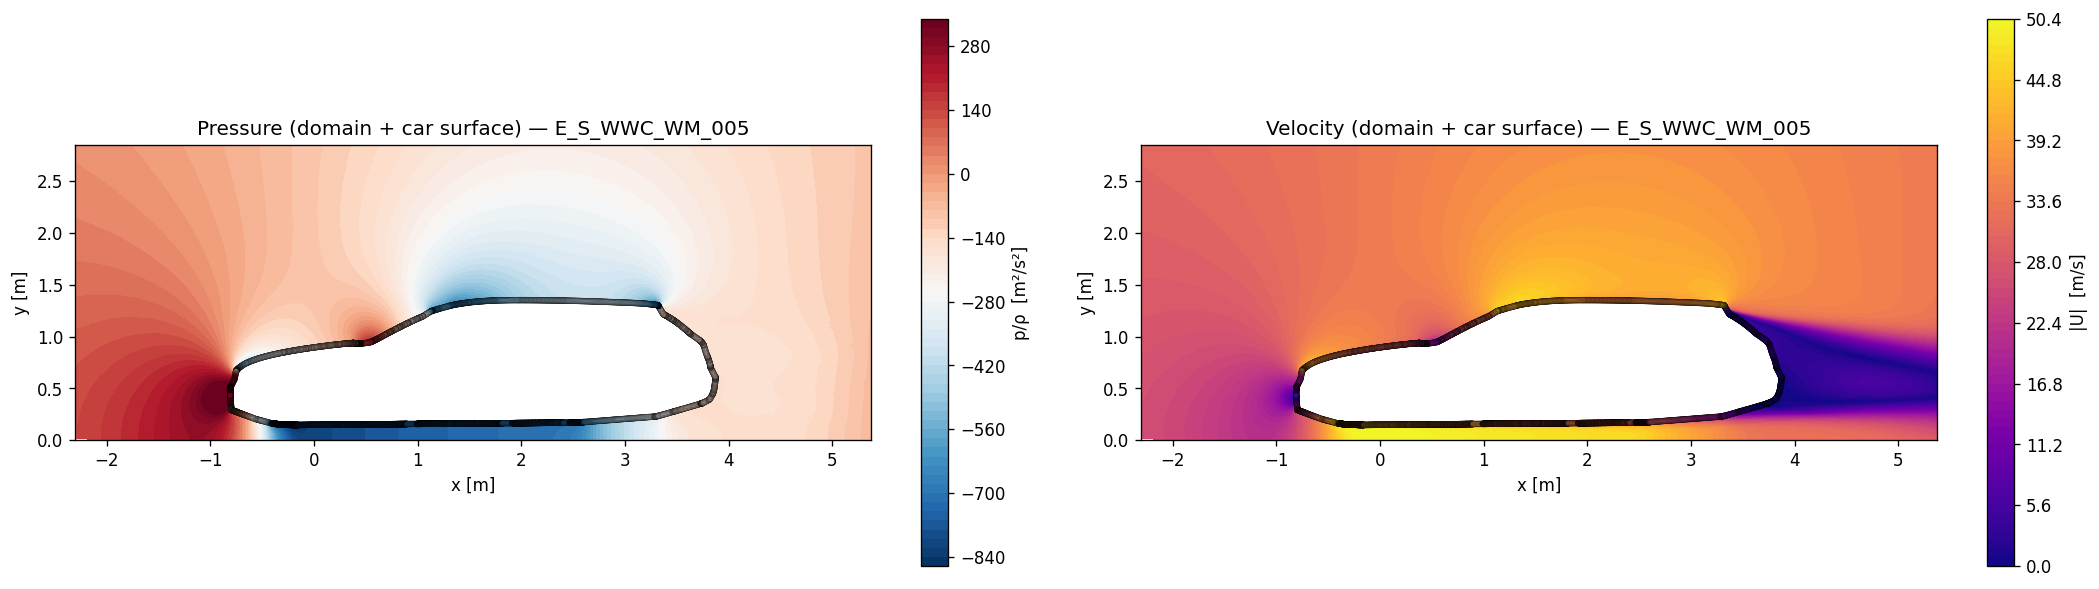

In [ ]:
# Zoom into the car region
pad = 1.5
x_lo, x_hi = s_x.min() - pad, s_x.max() + pad
y_lo, y_hi = 0, s_y.max() + pad

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Pressure ────────────────────────────────────────────────
tcf1 = axes[0].tricontourf(triang, p_clip, levels=64, cmap="RdBu_r")
axes[0].scatter(s_x, s_y, c=s_p, s=12, cmap="RdBu_r", edgecolors="k", linewidths=0.3,
                vmin=p_clip.min(), vmax=p_clip.max(), zorder=5)
fig.colorbar(tcf1, ax=axes[0], label="p/ρ  [m²/s²]", shrink=0.8)
axes[0].set_xlim(x_lo, x_hi)
axes[0].set_ylim(y_lo, y_hi)
axes[0].set_xlabel("x [m]")
axes[0].set_ylabel("y [m]")
axes[0].set_title(f"Pressure (domain + car surface) — {CASE_NAME}")
axes[0].set_aspect("equal")

# ── Velocity ────────────────────────────────────────────────
tcf2 = axes[1].tricontourf(triang, U_mag_clip, levels=64, cmap="plasma")
axes[1].scatter(s_x, s_y, c=s_Umag, s=12, cmap="plasma", edgecolors="k", linewidths=0.3,
                vmin=0, vmax=U_mag_clip.max(), zorder=5)
fig.colorbar(tcf2, ax=axes[1], label="|U|  [m/s]", shrink=0.8)
axes[1].set_xlim(x_lo, x_hi)
axes[1].set_ylim(y_lo, y_hi)
axes[1].set_xlabel("x [m]")
axes[1].set_ylabel("y [m]")
axes[1].set_title(f"Velocity (domain + car surface) — {CASE_NAME}")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

---

## 11. HF vs LF Comparison at y = 0 (Car Symmetry Plane)

Extract the **y = 0** (symmetry-plane) cross-section from a high-fidelity 3D VTK pressure surface and overlay it with the corresponding low-fidelity 2D car wall outline.

| Dataset | Axes plotted | Source |
|---------|-------------|--------|
| HF VTK  | x vs z (at y ≈ 0) | 3D surface mesh sliced at the spanwise symmetry plane |
| LF npz  | s_x vs s_y        | 2D car-wall boundary exported from OpenFOAM |

In [19]:
import pyvista as pv

# ── HF Configuration ──────────────────────────────────────────
VTK_DIR = Path("/home/nicksung/Desktop/nicksung/mf_field/hf_data/PressureVTK")
HF_CASE = "E_S_WW_WM_005"   # ← change to desired HF case
Y_TOL   = 0.02               # tolerance for y ≈ 0 slice [m]

# Load HF mesh
mesh = pv.read(VTK_DIR / f"{HF_CASE}.vtk")
pts    = mesh.points              # (N, 3)  x, y, z
p_hf   = mesh.point_data["p"]    # pressure at each point

# Extract y ≈ 0 slice (symmetry plane)
mask_hf = np.abs(pts[:, 1]) < Y_TOL
hf_x = pts[mask_hf, 0]
hf_z = pts[mask_hf, 2]
hf_p = p_hf[mask_hf]

print(f"HF case   : {HF_CASE}")
print(f"  Total points     : {len(pts):,}")
print(f"  y≈0 slice points : {mask_hf.sum():,}  (|y| < {Y_TOL} m)")
print(f"  x range : [{hf_x.min():.3f}, {hf_x.max():.3f}]")
print(f"  z range : [{hf_z.min():.3f}, {hf_z.max():.3f}]")
print(f"  p range : [{hf_p.min():.1f}, {hf_p.max():.1f}]")

HF case   : E_S_WW_WM_005
  Total points     : 521,713
  y≈0 slice points : 6,799  (|y| < 0.02 m)
  x range : [-0.817, 3.829]
  z range : [0.147, 1.357]
  p range : [-704.6, 450.1]


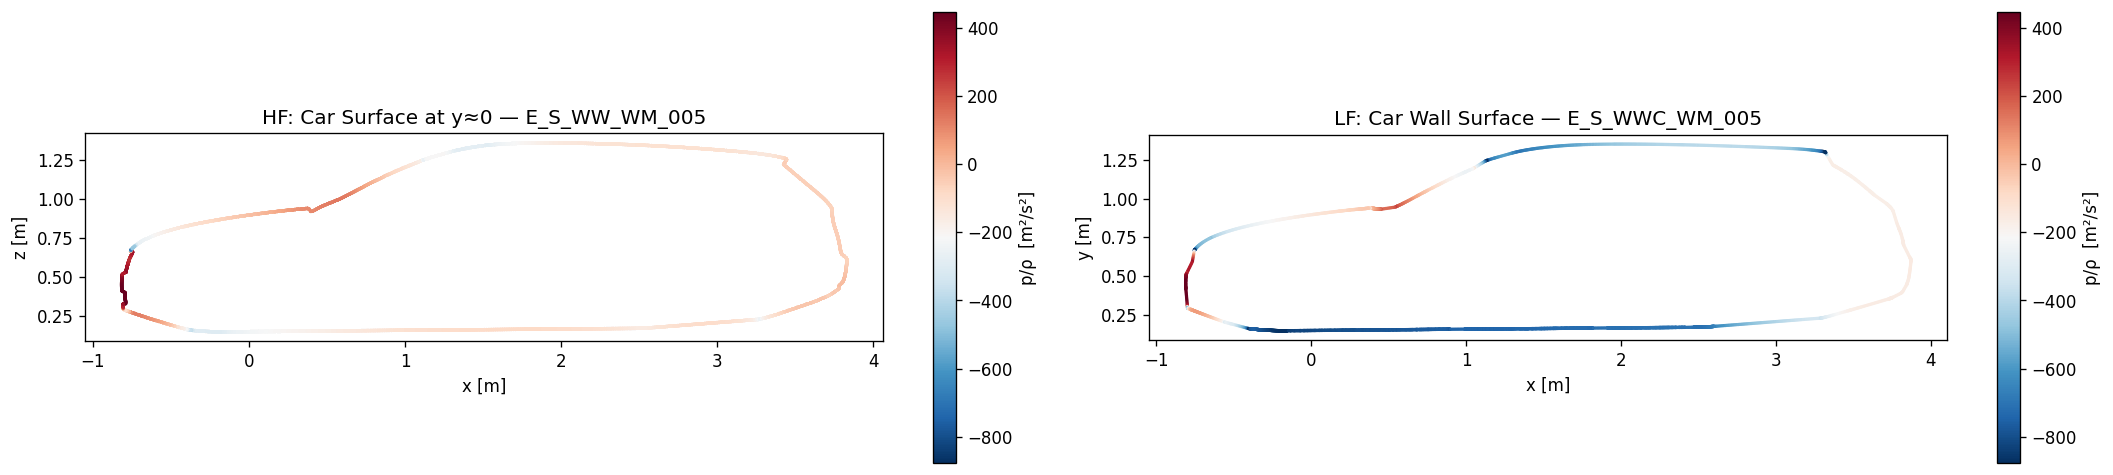

In [20]:
# ── Side-by-side: HF y=0 outline vs LF surface outline ────────
# Shared colour limits clipped to 1–99th percentile across both datasets
p_lo = min(np.percentile(hf_p, 1),  np.percentile(s_p, 1))
p_hi = max(np.percentile(hf_p, 99), np.percentile(s_p, 99))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# ── HF: car surface at y ≈ 0 ─────────────────────────────────
sc1 = axes[0].scatter(hf_x, hf_z, c=hf_p, s=4, cmap="RdBu_r",
                      vmin=p_lo, vmax=p_hi, edgecolors="none")
fig.colorbar(sc1, ax=axes[0], label="p/ρ  [m²/s²]", shrink=0.8)
axes[0].set_xlabel("x [m]")
axes[0].set_ylabel("z [m]")
axes[0].set_title(f"HF: Car Surface at y≈0 — {HF_CASE}")
axes[0].set_aspect("equal")

# ── LF: 2D car wall surface ───────────────────────────────────
sc2 = axes[1].scatter(s_x, s_y, c=s_p, s=4, cmap="RdBu_r",
                      vmin=p_lo, vmax=p_hi, edgecolors="none")
fig.colorbar(sc2, ax=axes[1], label="p/ρ  [m²/s²]", shrink=0.8)
axes[1].set_xlabel("x [m]")
axes[1].set_ylabel("y [m]")
axes[1].set_title(f"LF: Car Wall Surface — {CASE_NAME}")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

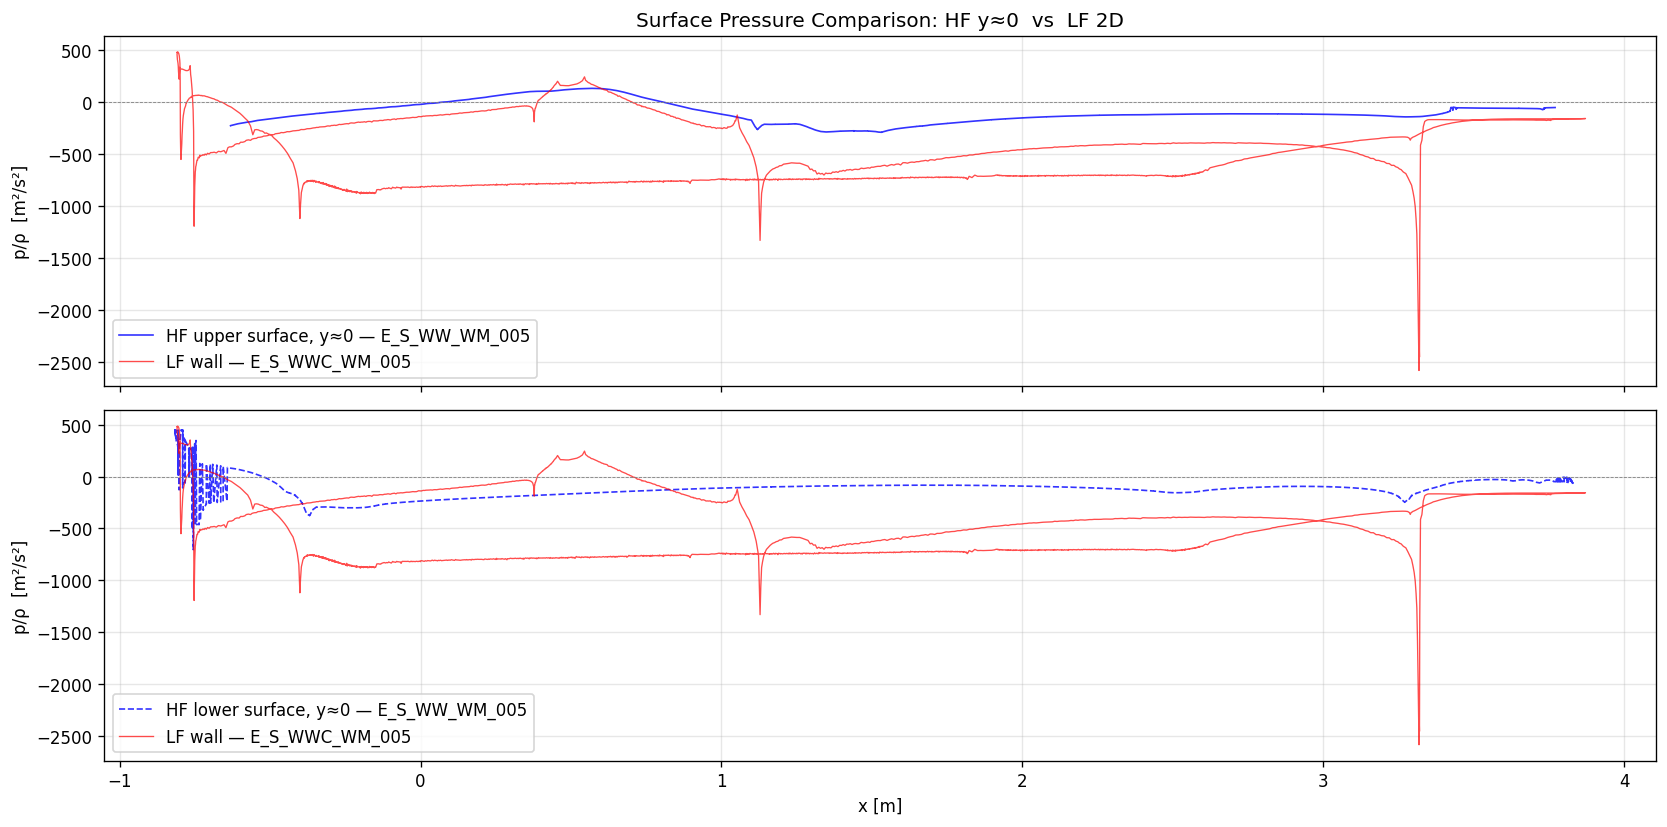

In [21]:
# ── Pressure along x: HF (y≈0) vs LF surface ─────────────────
# Sort HF slice by x so the line plot is clean
sort_idx = np.argsort(hf_x)
hf_xs, hf_zs, hf_ps = hf_x[sort_idx], hf_z[sort_idx], hf_p[sort_idx]

# Split into roof (upper half) and underside (lower half) using z median
z_mid = (hf_zs.max() + hf_zs.min()) / 2
mask_upper = hf_zs >= z_mid
mask_lower = hf_zs < z_mid

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# ── Top surface / roof ────────────────────────────────────────
axes[0].plot(hf_xs[mask_upper], hf_ps[mask_upper],
             "b-", lw=1.0, alpha=0.8, label=f"HF upper surface, y≈0 — {HF_CASE}")
axes[0].plot(s_x, s_p, "r-", lw=0.8, alpha=0.7, label=f"LF wall — {CASE_NAME}")
axes[0].axhline(0, color="gray", ls="--", lw=0.5)
axes[0].set_ylabel("p/ρ  [m²/s²]")
axes[0].set_title("Surface Pressure Comparison: HF y≈0  vs  LF 2D")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Underside ─────────────────────────────────────────────────
axes[1].plot(hf_xs[mask_lower], hf_ps[mask_lower],
             "b--", lw=1.0, alpha=0.8, label=f"HF lower surface, y≈0 — {HF_CASE}")
axes[1].plot(s_x, s_p, "r-", lw=0.8, alpha=0.7, label=f"LF wall — {CASE_NAME}")
axes[1].axhline(0, color="gray", ls="--", lw=0.5)
axes[1].set_xlabel("x [m]")
axes[1].set_ylabel("p/ρ  [m²/s²]")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

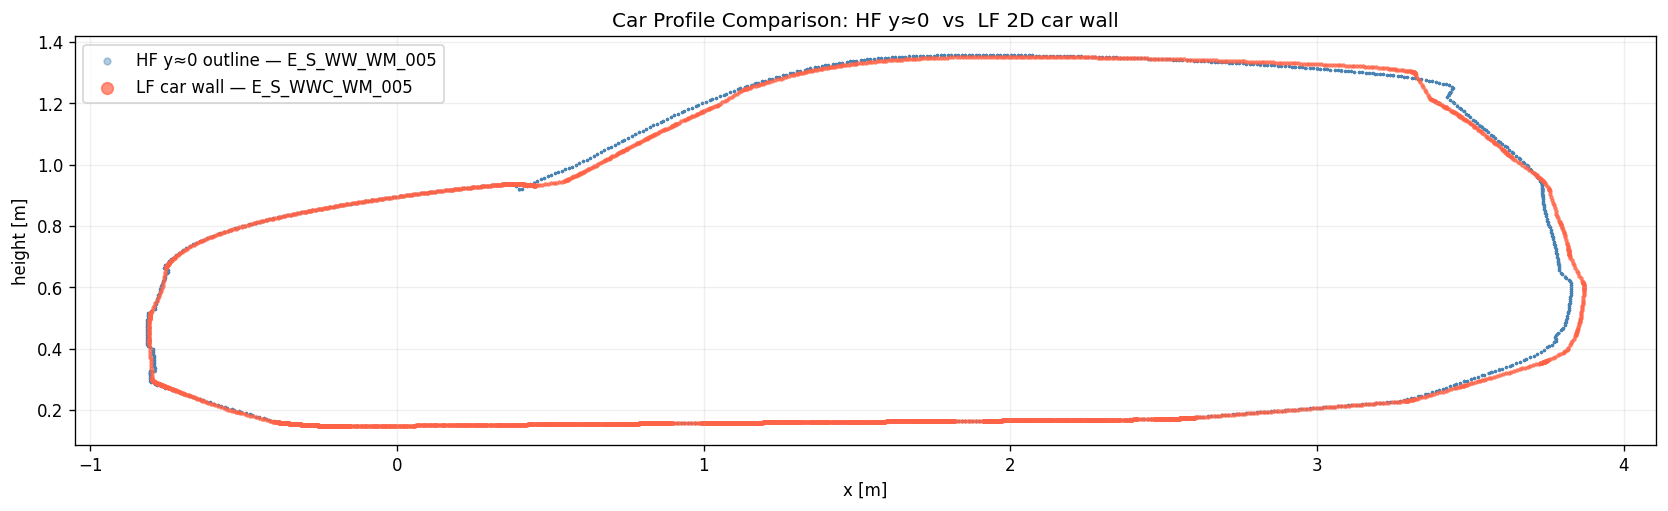

In [22]:
# ── Geometry overlay: HF y=0 silhouette vs LF 2D outline ──────
fig, ax = plt.subplots(figsize=(14, 5))

# HF: scatter all y≈0 points (silhouette of 3D shape at symmetry plane)
ax.scatter(hf_x, hf_z, s=1, color="steelblue", alpha=0.4,
           label=f"HF y≈0 outline — {HF_CASE}")

# LF: car wall face centres
ax.scatter(s_x, s_y, s=3, color="tomato", alpha=0.7,
           label=f"LF car wall — {CASE_NAME}")

ax.set_xlabel("x [m]")
ax.set_ylabel("height [m]")
ax.set_title("Car Profile Comparison: HF y≈0  vs  LF 2D car wall")
ax.set_aspect("equal")
ax.legend(markerscale=4)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()